# 🤗 Fine-Tuning de Transformers

Comparamos modelos de lenguaje pre-entrenados (Transformers) fine-tuneados
en nuestro dataset contra el modelo LR+TF-IDF que ya teníamos.

Los modelos como DistilBERT o RoBERTa ya fueron entrenados en **millones de páginas**
de internet. Ya 'saben' inglés. Nosotros solo tenemos que enseñarles a distinguir
comentarios tóxicos de los que no lo son — y para eso, 700 muestras son suficientes.

Es la diferencia entre contratar a un experto en inglés y enseñarle hate speech
(Transformer) vs enseñar hate speech a alguien que no sabe inglés (TF-IDF).

### Modelos que comparamos

| # | Modelo | Tipo | Especialización |
|---|---|---|---|
| 1 | **LR + TF-IDF** | Referencia | Entrenado por nosotros |
| 2 | **DistilBERT base** | Transformer general | Ninguna — aprende de cero nuestra tarea |
| 3 | **toxic-comment-model** | DistilBERT especializado | Ya fine-tuneado en toxicidad |
| 4 | **RoBERTa Hate** | RoBERTa especializado | Ya fine-tuneado en hate speech de Twitter |

Los modelos 3 y 4 ya saben detectar toxicidad — solo los adaptamos a nuestro dominio.

### ¿Qué es zero-shot?
Evaluamos los modelos especializados (3 y 4) **sin ningún fine-tuning** para ver
cuánto saben ya. Esto nos da la referencia mínima antes de entrenar.

### Output
- Tabla comparativa completa: LR vs 3 transformers
- Modelo ganador guardado en `models/finetuned_hf/` (listo para Streamlit)
- Experimento registrado en MLflow

## 0. Imports y configuración

Instalación necesaria (ejecutar una sola vez en tu entorno):
```bash
pip install transformers datasets accelerate torch sentencepiece
```

In [1]:
import os
import sys
import yaml
import json
import joblib
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import mlflow
import mlflow.pytorch

from pathlib import Path
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    accuracy_score, roc_auc_score,
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, TrainingArguments,
    Trainer, EarlyStoppingCallback, pipeline,
)

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Cargar config
with open(PROJECT_ROOT / 'configs' / 'pipeline.yaml') as f:
    pipe_cfg = yaml.safe_load(f)

TARGET    = pipe_cfg['data']['target_binary']
RAND      = pipe_cfg['pipeline']['random_state']
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 55)
print(f'Torch version : {torch.__version__}')
print(f'Device        : {device}')
if torch.cuda.is_available():
    print(f'GPU           : {torch.cuda.get_device_name(0)}')
    print(f'VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('GPU           : No detectada — el entrenamiento será más lento')
print('=' * 55)

/home/under/miniconda3/envs/py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch version : 2.12.0+cu132
Device        : cuda
GPU           : NVIDIA GeForce RTX 2060
VRAM          : 6.4 GB


## 1. Reproducibilidad

### ¿Por qué es importante?
Los modelos de deep learning tienen inicialización aleatoria de pesos.
Si no fijamos la semilla, el mismo código puede dar resultados distintos en
cada ejecución, haciendo imposible comparar experimentos de forma justa.

Fijamos la semilla en 4 lugares:
- `random` → shuffle de datos en Python
- `numpy` → operaciones numéricas
- `torch` → la red neuronal
- `cuda` → operaciones en GPU

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(RAND)
print(f'Semilla fijada: {RAND}')

Semilla fijada: 42


## 2. Carga de datos

### ¡IMPORTANTE! Usamos `Text` crudo, NO `clean_text`

En los notebooks anteriores preprocesamos el texto (stopwords, lematización).
Para transformers eso es **contraproducente**:

- DistilBERT y RoBERTa tienen su propio tokenizador interno
- Entienden contexto: 'running' y 'run' significan cosas distintas según la frase
- Lematizar destruye información que los modelos de atención pueden aprovechar
- Eliminar stopwords como 'not' puede cambiar el sentido de 'not toxic' → 'toxic'

**Regla:** sklearn necesita texto limpio. Transformers necesitan texto crudo.

In [3]:
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'v2' / 'comments_preprocessed.csv'

df = pd.read_csv(DATA_PATH)

# Usamos Text (crudo), no clean_text
TEXT_COL = 'Text'
df[TEXT_COL] = df[TEXT_COL].fillna('').astype(str).str.strip()
df = df[df[TEXT_COL] != ''].copy()
df[TARGET] = df[TARGET].astype(int)

print(f'Dataset: {df.shape}')
print(f'Columna texto: {TEXT_COL}')
print(f'Toxicos: {df[TARGET].sum()} ({df[TARGET].mean()*100:.1f}%)')
print()
print('Muestra de texto crudo (lo que ven los transformers):')
for t in df[TEXT_COL].sample(3, random_state=42):
    print(f'  → {t[:100]}')

Dataset: (1000, 9)
Columna texto: Text
Toxicos: 462 (46.2%)

Muestra de texto crudo (lo que ven los transformers):
  → You call yourself an anarchist but defend a cop shooting an unarmed civilian. I'm highly disappointe
  → My mother told me the same thing.  God Bless this woman.
  → Love it I same the saem thing Go Peggy!  #stupid  
Ya Killing ya selves more quicker than  STLPD cou


## 3. Split train / validation / test

### ¿Por qué 3 conjuntos en vez de 2+CV?

En los notebooks de sklearn usamos **StratifiedKFold** porque entrenar
Logistic Regression 5 veces tarda segundos.

Con transformers, **una sola epoch** puede tardar 2-5 minutos.
Hacer 5-fold CV significaría 15+ epochs de entrenamiento por modelo — inviable.

La solución es el split de 3 vías:
```
TOTAL (1000)
├── TRAIN (700) → el modelo aprende aquí
├── VALIDATION (150) → EarlyStoppingCallback mira esto para no sobreajustar
└── TEST (150) → evaluación final, se toca UNA sola vez
```

El validation set hace el trabajo que hacía el CV: detecta cuándo el modelo
empieza a memorizar en vez de aprender.

In [4]:
X = df[TEXT_COL]
y = df[TARGET]

# Separar test final (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RAND
)

# Separar validation del train restante
# 0.1765 del 85% ≈ 15% del total
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=RAND
)

print('SPLITS')
print(f'  Train     : {len(X_train):>4} ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Validation: {len(X_valid):>4} ({len(X_valid)/len(X)*100:.0f}%)')
print(f'  Test      : {len(X_test):>4}  ({len(X_test)/len(X)*100:.0f}%)')
print()
print('Toxicos en cada split:')
for name, yy in [('Train', y_train), ('Val', y_valid), ('Test', y_test)]:
    print(f'  {name}: {yy.sum()} / {len(yy)} ({yy.mean()*100:.1f}%)')

SPLITS
  Train     :  699 (70%)
  Validation:  151 (15%)
  Test      :  150  (15%)

Toxicos en cada split:
  Train: 323 / 699 (46.2%)
  Val: 70 / 151 (46.4%)
  Test: 69 / 150 (46.0%)


## 4. Referencia — LR + TF-IDF

Cargamos el modelo del notebook 06 y lo evaluamos sobre el **mismo test set**
para tener una comparación justa.

**Atención:** el LR fue entrenado con `clean_text`, no con `Text`.
Aquí aplicamos el preprocesador de scikit-learn que viene embebido en el pipeline.

In [5]:
# Cargar el pipeline sklearn completo (incluye TF-IDF + LR)
lr_path = PROJECT_ROOT / 'models' / 'final_model.joblib'

if lr_path.exists():
    lr_pipeline = joblib.load(lr_path)
    print(f'Modelo LR cargado: {lr_path.name}')

    # El pipeline sklearn usa clean_text internamente
    # Lo evaluamos sobre el texto crudo — el preprocesador está dentro
    # Si el modelo fue guardado con texto ya limpio, cargar el preprocessor
    try:
        from src.features.text_preprocessor import TextPreprocessor
        prep = TextPreprocessor(
            config_path=str(PROJECT_ROOT / 'configs' / 'features.yaml')
        )
        X_test_clean = prep.transform(X_test)
        lr_preds = lr_pipeline.predict(X_test_clean)
        lr_probs = lr_pipeline.predict_proba(X_test_clean)[:, 1]
    except Exception:
        # Fallback: el pipeline ya maneja el texto crudo
        lr_preds = lr_pipeline.predict(X_test)
        lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]

    lr_ref = {
        'f1'       : f1_score(y_test, lr_preds, average='weighted'),
        'precision': precision_score(y_test, lr_preds, average='weighted'),
        'recall'   : recall_score(y_test, lr_preds, average='weighted'),
        'roc_auc'  : roc_auc_score(y_test, lr_probs),
        'fp'       : int(((y_test==0)&(lr_preds==1)).sum()),
        'fn'       : int(((y_test==1)&(lr_preds==0)).sum()),
    }
    print(f"LR F1={lr_ref['f1']:.4f} | ROC-AUC={lr_ref['roc_auc']:.4f}")
    print(f"LR FP={lr_ref['fp']} | FN={lr_ref['fn']}")
else:
    print('Modelo LR no encontrado. Ejecuta el notebook 06 primero.')
    lr_ref = None

Modelo LR cargado: final_model.joblib
LR F1=0.6944 | ROC-AUC=0.7794
LR FP=15 | FN=30


## 5. Funciones auxiliares

Creamos funciones reutilizables para no repetir código en cada modelo.
El patrón es siempre el mismo:
1. Convertir pandas DataFrame a HuggingFace Dataset
2. Tokenizar (convertir texto a números)
3. Entrenar con Trainer
4. Evaluar y comparar

In [6]:
# ── Dataset ──────────────────────────────────────────────────────────────
def build_hf_dataset(X, y) -> Dataset:
    """
    Convierte pandas Series a HuggingFace Dataset.
    HuggingFace Dataset es el formato que acepta el Trainer.
    """
    return Dataset.from_pandas(pd.DataFrame({
        'text' : X.values,
        'label': y.astype(int).values,
    }))

# ── Tokenización ─────────────────────────────────────────────────────────
def tokenize_dataset(dataset: Dataset, tokenizer, max_len: int = 128) -> Dataset:
    """
    Tokeniza el texto: convierte palabras a IDs numéricos que el modelo entiende.

    Ejemplo: 'you are stupid' → [101, 2017, 2024, 5236, 102]
    donde 101=[CLS] y 102=[SEP] son tokens especiales de BERT.

    max_len=128: comentarios de YouTube son cortos, 128 tokens es suficiente.
    truncation=True: si un comentario es más largo, lo cortamos.
    """
    def _tokenize(batch):
        return tokenizer(batch['text'], truncation=True, max_length=max_len)

    dataset = dataset.map(_tokenize, batched=True)
    dataset = dataset.remove_columns(['text'])
    dataset.set_format('torch')
    return dataset

# ── Métricas ─────────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    """
    El Trainer llama a esta función al final de cada epoch de validación.
    Usamos F1 de la clase tóxica como métrica principal para:
    1. Elegir el mejor epoch (metric_for_best_model)
    2. Activar early stopping cuando deja de mejorar
    """
    logits, labels = eval_pred
    # logits: puntuaciones crudas del modelo → softmax → probabilidades
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    preds = np.argmax(logits, axis=1)
    return {
        'f1_toxic'  : f1_score(labels, preds, pos_label=1),
        'f1_weighted': f1_score(labels, preds, average='weighted'),
        'precision' : precision_score(labels, preds, pos_label=1, zero_division=0),
        'recall'    : recall_score(labels, preds, pos_label=1, zero_division=0),
        'roc_auc'   : roc_auc_score(labels, probs),
    }

# ── Evaluación final ─────────────────────────────────────────────────────
def evaluate_on_test(trainer, hf_test, y_test_arr, model_name: str) -> dict:
    """
    Evaluación final sobre el test set.
    Solo se llama UNA vez, después de que el modelo ya está entrenado.
    """
    output = trainer.predict(hf_test)
    probs  = torch.softmax(torch.tensor(output.predictions), dim=1)[:, 1].numpy()
    preds  = np.argmax(output.predictions, axis=1)

    print(f'\n{"="*55}')
    print(f'{model_name}')
    print(f'{"="*55}')
    print(classification_report(
        y_test_arr, preds,
        target_names=['No tóxico', 'Tóxico']
    ))

    # Matriz de confusión
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        confusion_matrix(y_test_arr, preds),
        annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['No tóxico','Tóxico'],
        yticklabels=['No tóxico','Tóxico'],
    )
    ax.set_title(f'{model_name} — Confusion Matrix')
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
    plt.tight_layout()
    safe_name = model_name.lower().replace(' ','_').replace('/','_')
    plt.savefig(
        PROJECT_ROOT / 'reports' / 'v2' / f'nb08_{safe_name}_cm.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()

    return {
        'model'    : model_name,
        'f1'       : round(f1_score(y_test_arr, preds, average='weighted'), 4),
        'f1_toxic' : round(f1_score(y_test_arr, preds, pos_label=1), 4),
        'precision': round(precision_score(y_test_arr, preds, average='weighted'), 4),
        'recall'   : round(recall_score(y_test_arr, preds, average='weighted'), 4),
        'roc_auc'  : round(roc_auc_score(y_test_arr, probs), 4),
        'fp'       : int(((y_test_arr==0)&(preds==1)).sum()),
        'fn'       : int(((y_test_arr==1)&(preds==0)).sum()),
        'preds'    : preds,
        'probs'    : probs,
    }

print('Funciones auxiliares definidas')

Funciones auxiliares definidas


## 6. Función de fine-tuning

Encapsulamos todo el proceso de entrenamiento en una función reutilizable.
Así no repetimos código para cada modelo.

In [ ]:
def fine_tune(
    model_id: str,
    hf_train, hf_valid, hf_test,
    y_test_arr,
    model_name: str,
    output_dir: Path,
    freeze_backbone: bool = False,
    unfreeze_last_n: int = 0,   # ← AÑADIR
    epochs: int = 5,
    lr: float = 2e-5,
    batch_size: int = 8,
    max_len: int = 128,
) -> dict:
    """
    Entrena (fine-tune) un modelo de HuggingFace y lo evalúa.

    Parámetros:
        model_id       : nombre del modelo en HuggingFace Hub
        freeze_backbone: Si True, congela el encoder — solo entrena la cabeza
                         clasificadora. Recomendado para modelos ya especializados
                         o cuando el dataset es muy pequeño.
        epochs         : máximo de epochs (early stopping puede parar antes)
        lr             : tasa de aprendizaje. 2e-5 es el estándar para BERT
        batch_size     : muestras por paso. Más pequeño = más updates, más robusto
    """
    print(f'\nCargando {model_id}...')
    set_seed(RAND)

    # Tokenizador
    tokenizer = AutoTokenizer.from_pretrained(model_id)

    # Tokenizar datasets
    tok_train = tokenize_dataset(hf_train, tokenizer, max_len)
    tok_valid = tokenize_dataset(hf_valid, tokenizer, max_len)
    tok_test  = tokenize_dataset(hf_test,  tokenizer, max_len)

    # Modelo de clasificación binaria (num_labels=2: no tóxico / tóxico)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_id, num_labels=2, ignore_mismatched_sizes=True
    )
    model.to(device)

    # ── Congelar el backbone (opcional) ──────────────────────────────────
    if freeze_backbone:

        # Paso 1: congelar TODOS los parámetros del encoder
        for param in model.base_model.parameters():
            param.requires_grad = False

        # Paso 2: descongelar las últimas N capas transformer (si se pide)
        # Funciona con DistilBERT (6 capas) y RoBERTa (12 capas)
        if unfreeze_last_n > 0:
            layers = None
            # Detecta automáticamente la arquitectura del modelo
            for attr_path in ['transformer.layer', 'encoder.layer']:
                try:
                    obj = model.base_model
                    for part in attr_path.split('.'):
                        obj = getattr(obj, part)
                    layers = list(obj)
                    break
                except AttributeError:
                    continue

            if layers:
                for layer in layers[-unfreeze_last_n:]:
                    for param in layer.parameters():
                        param.requires_grad = True
                print(f'  Últimas {unfreeze_last_n}/{len(layers)} capas descongeladas')
            else:
                print('  ⚠️ No se encontraron capas — solo cabeza entrenará')

        # Paso 3: siempre descongelar la cabeza clasificadora
        for name, param in model.named_parameters():
            if 'classifier' in name or 'pre_classifier' in name:
                param.requires_grad = True

        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in model.parameters())
        print(f'  Entrenando {trainable:,}/{total:,} params ({trainable/total*100:.1f}%)')

    else:
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'  Full fine-tuning — {trainable:,} params')

    # ── TrainingArguments ────────────────────────────────────────────────
    args = TrainingArguments(
        output_dir               = str(output_dir),
        learning_rate            = lr,
        num_train_epochs         = epochs,
        per_device_train_batch_size = batch_size,
        per_device_eval_batch_size  = batch_size,
        weight_decay             = 0.01,      # Regularización L2 en los pesos
        eval_strategy            = 'epoch',   # Evaluar al final de cada epoch
        save_strategy            = 'epoch',
        load_best_model_at_end   = True,      # Al terminar, cargar el mejor checkpoint
        metric_for_best_model    = 'f1_toxic',# Optimizar F1 de la clase tóxica
        greater_is_better        = True,
        warmup_ratio             = 0.1,       # 10% primeros pasos con LR creciente
        logging_steps            = 20,
        fp16                     = torch.cuda.is_available(),
        report_to                = 'none',
        seed                     = RAND,
    )

    # ── Trainer ──────────────────────────────────────────────────────────
    trainer = Trainer(
        model           = model,
        args            = args,
        train_dataset   = tok_train,
        eval_dataset    = tok_valid,
        data_collator   = DataCollatorWithPadding(tokenizer),
        compute_metrics = compute_metrics,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
    )

    # ── Entrenamiento ────────────────────────────────────────────────────
    print(f'  Entrenando (max {epochs} epochs, early stopping patience=2)...')
    trainer.train()

    # ── Evaluación en test ───────────────────────────────────────────────
    results = evaluate_on_test(trainer, tok_test, y_test_arr, model_name)
    results['trainer']   = trainer
    results['tokenizer'] = tokenizer

    return results

print('Función fine_tune definida')

Función fine_tune definida


## 7. Crear HuggingFace Datasets

Convertimos los pandas DataFrames al formato que usa la librería `transformers`.

In [8]:
hf_train_raw = build_hf_dataset(X_train, y_train)
hf_valid_raw = build_hf_dataset(X_valid, y_valid)
hf_test_raw  = build_hf_dataset(X_test,  y_test)

print(f'Train dataset : {hf_train_raw}')
print(f'Valid dataset : {hf_valid_raw}')
print(f'Test dataset  : {hf_test_raw}')

Train dataset : Dataset({
    features: ['text', 'label'],
    num_rows: 699
})
Valid dataset : Dataset({
    features: ['text', 'label'],
    num_rows: 151
})
Test dataset  : Dataset({
    features: ['text', 'label'],
    num_rows: 150
})


## 8. Evaluación zero-shot (sin fine-tuning)

### ¿Qué es zero-shot?
Evaluamos los modelos pre-especializados tal como están, **sin ningún entrenamiento**
adicional sobre nuestros datos.

Esto nos dice:
- ¿Cuánto saben ya estos modelos sobre toxicidad?
- ¿Merece la pena fine-tunearlos o ya son suficientemente buenos?
- Nos da el límite inferior antes de entrenar

Si zero-shot ya supera al LR, el fine-tuning lo mejorará aún más.

In [10]:
ZERO_SHOT_MODELS = [
    ('martin-ha/toxic-comment-model',        'ZeroShot-DistilBERT-Toxic'),
    ('cardiffnlp/twitter-roberta-base-hate', 'ZeroShot-RoBERTa-Hate'),
]

zero_shot_results = []
y_test_arr = y_test.values

for model_id, name in ZERO_SHOT_MODELS:
    print(f'\nEvaluando zero-shot: {model_id}')
    try:
        clf = pipeline(
            'text-classification',
            model=model_id,
            top_k=None,          # reemplaza return_all_scores=True (deprecado)
            truncation=True,
            max_length=128,
            device=0 if torch.cuda.is_available() else -1,
        )

        probs_all, preds = [], []

        for text in X_test:
            out = clf(text[:512])

            # ── Fix: normalizar formato de salida ──────────────────────────
            # Dependiendo de la versión de transformers, el formato varía:
            # Versión nueva: [{label, score}, {label, score}]  → lista de dicts
            # Versión vieja: [[{label, score}, {label, score}]] → lista de listas
            if isinstance(out[0], list):
                raw_scores = out[0]   # formato antiguo: desenvuelve un nivel
            elif isinstance(out[0], dict):
                raw_scores = out      # formato nuevo: ya es lista de dicts
            else:
                raw_scores = []

            scores = {s['label'].lower(): s['score'] for s in raw_scores}

            # Buscar la probabilidad de la clase tóxica
            # Cada modelo usa nombres distintos para sus etiquetas
            prob_toxic = (
                scores.get('label_1') or   # formato genérico LABEL_1
                scores.get('hate') or       # cardiffnlp usa 'hate'
                scores.get('toxic') or      # martin-ha usa 'toxic'
                scores.get('offensive') or  # algunos usan 'offensive'
                max(scores.values())        # fallback: tomar el mayor
            )

            probs_all.append(prob_toxic)
            preds.append(1 if prob_toxic >= 0.5 else 0)

        probs_all = np.array(probs_all)
        preds     = np.array(preds)

        res = {
            'model'    : name,
            'f1'       : round(f1_score(y_test_arr, preds, average='weighted'), 4),
            'f1_toxic' : round(f1_score(y_test_arr, preds, pos_label=1), 4),
            'precision': round(precision_score(y_test_arr, preds, average='weighted'), 4),
            'recall'   : round(recall_score(y_test_arr, preds, average='weighted'), 4),
            'roc_auc'  : round(roc_auc_score(y_test_arr, probs_all), 4),
            'fp'       : int(((y_test_arr==0)&(preds==1)).sum()),
            'fn'       : int(((y_test_arr==1)&(preds==0)).sum()),
        }
        zero_shot_results.append(res)
        print(f"  F1={res['f1']:.4f} | ROC-AUC={res['roc_auc']:.4f} | FP={res['fp']} | FN={res['fn']}")

    except Exception as e:
        print(f'  Error: {e}')
        zero_shot_results.append({'model': name, 'f1': None, 'error': str(e)})


Evaluando zero-shot: martin-ha/toxic-comment-model


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7757.56it/s]
[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  F1=0.6670 | ROC-AUC=0.8048 | FP=12 | FN=36

Evaluando zero-shot: cardiffnlp/twitter-roberta-base-hate


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4811.71it/s]


  F1=0.4320 | ROC-AUC=0.7500 | FP=1 | FN=65


## 9. Fine-tuning — DistilBERT base (modelo general)

### ¿Qué es DistilBERT?
DistilBERT es una versión comprimida de BERT:
- 40% menos parámetros que BERT-base
- 60% más rápido
- Mantiene el 97% de la capacidad de BERT

Es el punto de partida **generalista**: no sabe nada de toxicidad,
aprende todo desde los datos nuestros.

### ¿Por qué full fine-tuning aquí?
Como no tiene conocimiento previo de toxicidad, necesita actualizar
más parámetros para aprender. Usamos `freeze_backbone=False`.


Cargando distilbert-base-uncased...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 332.13it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Full fine-tuning — 66,955,010 parámetros entrenables
  Entrenando (max 5 epochs, early stopping patience=2)...


Epoch,Training Loss,Validation Loss,F1 Toxic,F1 Weighted,Precision,Recall,Roc Auc
1,0.602672,0.542350,0.677165,0.724665,0.754386,0.614286,0.805820
2,0.429105,0.551417,0.743590,0.734169,0.674419,0.828571,0.833598
3,0.263530,0.735574,0.737589,0.755075,0.732394,0.742857,0.814991
4,0.167136,0.923113,0.743590,0.734169,0.674419,0.828571,0.819136


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.27s/it]



DistilBERT base
              precision    recall  f1-score   support

   No tóxico       0.83      0.73      0.78        81
      Tóxico       0.72      0.83      0.77        69

    accuracy                           0.77       150
   macro avg       0.78      0.78      0.77       150
weighted avg       0.78      0.77      0.77       150



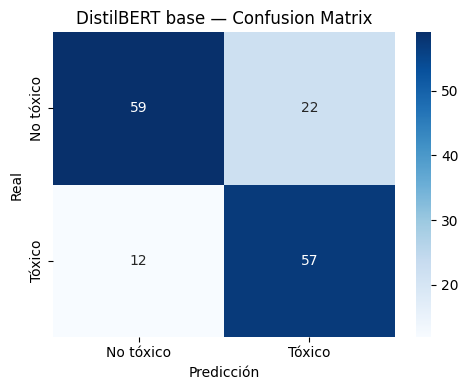

DistilBERT — F1=0.7735 | ROC-AUC=0.8561


In [11]:
results_distilbert = fine_tune(
    model_id        = 'distilbert-base-uncased',
    hf_train        = hf_train_raw,
    hf_valid        = hf_valid_raw,
    hf_test         = hf_test_raw,
    y_test_arr      = y_test_arr,
    model_name      = 'DistilBERT base',
    output_dir      = PROJECT_ROOT / 'models' / 'nb08_distilbert',
    freeze_backbone = False,   # General → fine-tuning completo
    epochs          = 5,
    lr              = 2e-5,
    batch_size      = 8,
)
print(f"DistilBERT — F1={results_distilbert['f1']:.4f} | ROC-AUC={results_distilbert['roc_auc']:.4f}")

## 10. Fine-tuning — DistilBERT especializado en toxicidad

### ¿Qué es martin-ha/toxic-comment-model?
Este modelo ES DistilBERT, pero ya fue fine-tuneado en el **dataset de Jigsaw**
(Wikipedia comments de toxicidad). Ya sabe mucho sobre comentarios tóxicos.

### ¿Por qué congelamos el backbone?
Como ya sabe de toxicidad, si actualizamos todos sus pesos con solo 700 muestras,
podemos 'desaprender' lo que ya sabe (fenómeno llamado *catastrophic forgetting*).

Estrategia: congelar todo el encoder y solo entrenar la cabeza clasificadora.
Esto es como contratar a un experto en toxicidad y solo enseñarle el
vocabulario específico de videos de YouTube.


Cargando martin-ha/toxic-comment-model...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7684.04it/s]
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Backbone congelado — entrenando 592,130/66,955,010 parámetros (0.9%)
  Entrenando (max 5 epochs, early stopping patience=2)...


Epoch,Training Loss,Validation Loss,F1 Toxic,F1 Weighted,Precision,Recall,Roc Auc
1,0.585069,0.552983,0.666667,0.727579,0.800000,0.571429,0.792593
2,0.558594,0.548867,0.666667,0.727579,0.800000,0.571429,0.792769
3,0.548882,0.546985,0.672000,0.723691,0.763636,0.600000,0.794004
4,0.550528,0.546289,0.672131,0.728803,0.788462,0.585714,0.794356
5,0.525463,0.546133,0.672131,0.728803,0.788462,0.585714,0.794356


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.48s/it]



DistilBERT Toxic (fine-tuned)
              precision    recall  f1-score   support

   No tóxico       0.69      0.81      0.75        81
      Tóxico       0.72      0.57      0.63        69

    accuracy                           0.70       150
   macro avg       0.70      0.69      0.69       150
weighted avg       0.70      0.70      0.69       150



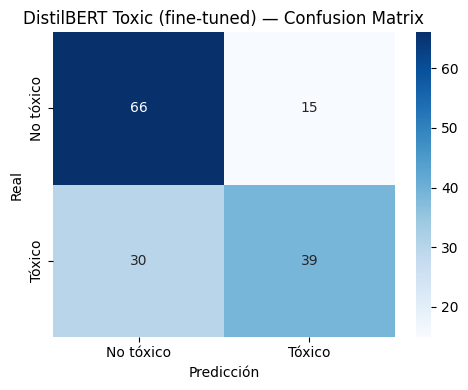

Toxic-DistilBERT — F1=0.6944 | ROC-AUC=0.8050


In [ ]:
results_toxic_distil = fine_tune(
    model_id        = 'martin-ha/toxic-comment-model',
    hf_train        = hf_train_raw,
    hf_valid        = hf_valid_raw,
    hf_test         = hf_test_raw,
    y_test_arr      = y_test_arr,
    model_name      = 'DistilBERT Toxic (fine-tuned)',
    output_dir      = PROJECT_ROOT / 'models' / 'nb08_toxic_distilbert',
    freeze_backbone = True,    # Especializado → solo entrena la cabeza
    unfreeze_last_n = 2,
    epochs          = 5,
    lr              = 3e-5,    # LR más alto porque solo entrenamos la cabeza
    batch_size      = 8,      # Batch más grande porque hay menos parámetros
)
print(f"Toxic-DistilBERT — F1={results_toxic_distil['f1']:.4f} | ROC-AUC={results_toxic_distil['roc_auc']:.4f}")

## 11. Fine-tuning — RoBERTa especializado en hate speech

### ¿Qué es cardiffnlp/twitter-roberta-base-hate?
RoBERTa es una versión mejorada de BERT (mismo tamaño, mejor entrenado).
Este modelo fue fine-tuneado específicamente en **tweets de hate speech**.

### ¿Por qué es potencialmente el mejor para nuestro caso?
- Twitter tiene comentarios cortos y agresivos — similar a YouTube
- El vocabulario incluye insultos, racismo, amenazas — exactamente lo que buscamos
- RoBERTa base > DistilBERT base en calidad

### ¿Por qué congelamos?
Misma razón que el anterior — no queremos destruir el conocimiento ya adquirido.


Cargando cardiffnlp/twitter-roberta-base-hate...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6507.36it/s]
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Backbone congelado — entrenando 592,130/124,647,170 parámetros (0.5%)
  Entrenando (max 5 epochs, early stopping patience=2)...


Epoch,Training Loss,Validation Loss,F1 Toxic,F1 Weighted,Precision,Recall,Roc Auc
1,0.572527,0.485615,0.655462,0.720098,0.795918,0.557143,0.860317
2,0.536939,0.451396,0.708661,0.751527,0.789474,0.642857,0.879718
3,0.497057,0.440219,0.764706,0.787516,0.787879,0.742857,0.882363
4,0.470336,0.439329,0.780822,0.788359,0.750000,0.814286,0.883951
5,0.470541,0.433991,0.762590,0.781341,0.768116,0.757143,0.883951


Writing model shards: 100%|██████████| 1/1 [00:06<00:00,  6.94s/it]



RoBERTa Hate
              precision    recall  f1-score   support

   No tóxico       0.70      0.70      0.70        81
      Tóxico       0.65      0.65      0.65        69

    accuracy                           0.68       150
   macro avg       0.68      0.68      0.68       150
weighted avg       0.68      0.68      0.68       150



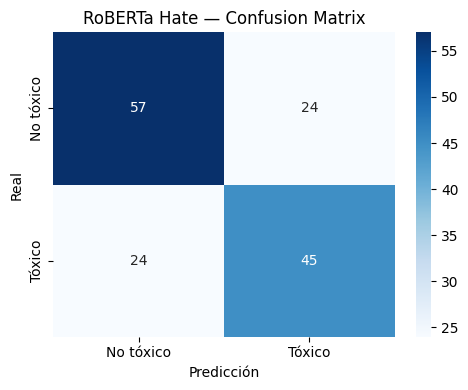

RoBERTa Hate — F1=0.6800 | ROC-AUC=0.8220


In [ ]:
results_roberta = fine_tune(
    model_id        = 'cardiffnlp/twitter-roberta-base-hate',
    hf_train        = hf_train_raw,
    hf_valid        = hf_valid_raw,
    hf_test         = hf_test_raw,
    y_test_arr      = y_test_arr,
    model_name      = 'RoBERTa Hate',
    output_dir      = PROJECT_ROOT / 'models' / 'nb08_roberta_hate',
    freeze_backbone = True,    # Especializado → solo cabeza
    unfreeze_last_n = 2,
    epochs          = 5,
    lr              = 3e-5,
    batch_size      = 8,
)
print(f"RoBERTa Hate — F1={results_roberta['f1']:.4f} | ROC-AUC={results_roberta['roc_auc']:.4f}")

## 12. Tabla comparativa completa

Comparamos todos los modelos sobre el **mismo test set** para
que la comparación sea justa.

Se incluyen:
- LR baseline (del notebook 06)
- Zero-shot (sin fine-tuning)
- Fine-tuned (con nuestros datos)

In [14]:
# Construir tabla con todos los modelos
all_results = []

# LR referencia
if lr_ref:
    all_results.append({
        'Modelo'    : 'LR + TF-IDF (nb06)',
        'Tipo'      : 'Baseline sklearn',
        'F1 weighted': lr_ref['f1'],
        'ROC-AUC'   : lr_ref['roc_auc'],
        'FP'        : lr_ref['fp'],
        'FN'        : lr_ref['fn'],
    })

# Zero-shot
for r in zero_shot_results:
    if r.get('f1') is not None:
        all_results.append({
            'Modelo'    : r['model'],
            'Tipo'      : 'Zero-shot',
            'F1 weighted': r['f1'],
            'ROC-AUC'   : r['roc_auc'],
            'FP'        : r['fp'],
            'FN'        : r['fn'],
        })

# Fine-tuned
for res, tipo in [
    (results_distilbert,   'Fine-tuned'),
    (results_toxic_distil, 'Fine-tuned'),
    (results_roberta,      'Fine-tuned'),
]:
    all_results.append({
        'Modelo'     : res['model'],
        'Tipo'       : tipo,
        'F1 weighted': res['f1'],
        'ROC-AUC'    : res['roc_auc'],
        'FP'         : res['fp'],
        'FN'         : res['fn'],
    })

comp_df = pd.DataFrame(all_results).sort_values('F1 weighted', ascending=False)

print('COMPARATIVA COMPLETA — todos los modelos')
print('=' * 80)
print(f"{'Modelo':35} {'Tipo':20} {'F1':>8} {'ROC-AUC':>9} {'FP':>4} {'FN':>4}")
print('-' * 80)
for _, row in comp_df.iterrows():
    marker = ' ← GANADOR' if row['F1 weighted'] == comp_df['F1 weighted'].max() else ''
    print(f"  {row['Modelo']:33} {row['Tipo']:20} {row['F1 weighted']:>8.4f} "
          f"{row['ROC-AUC']:>9.4f} {row['FP']:>4} {row['FN']:>4}{marker}")

best_row = comp_df.iloc[0]
print(f"\nGanador: {best_row['Modelo']}")
print(f"F1={best_row['F1 weighted']:.4f} | ROC-AUC={best_row['ROC-AUC']:.4f}")

# Mejora sobre LR baseline
if lr_ref:
    delta = (best_row['F1 weighted'] - lr_ref['f1']) * 100
    print(f"Mejora sobre LR: {delta:+.2f}pp")

COMPARATIVA COMPLETA — todos los modelos
Modelo                              Tipo                       F1   ROC-AUC   FP   FN
--------------------------------------------------------------------------------
  DistilBERT base                   Fine-tuned             0.7735    0.8561   22   12 ← GANADOR
  LR + TF-IDF (nb06)                Baseline sklearn       0.6944    0.7794   15   30
  DistilBERT Toxic (fine-tuned)     Fine-tuned             0.6944    0.8050   15   30
  RoBERTa Hate                      Fine-tuned             0.6800    0.8220   24   24
  ZeroShot-DistilBERT-Toxic         Zero-shot              0.6670    0.8048   12   36
  ZeroShot-RoBERTa-Hate             Zero-shot              0.4320    0.7500    1   65

Ganador: DistilBERT base
F1=0.7735 | ROC-AUC=0.8561
Mejora sobre LR: +7.91pp


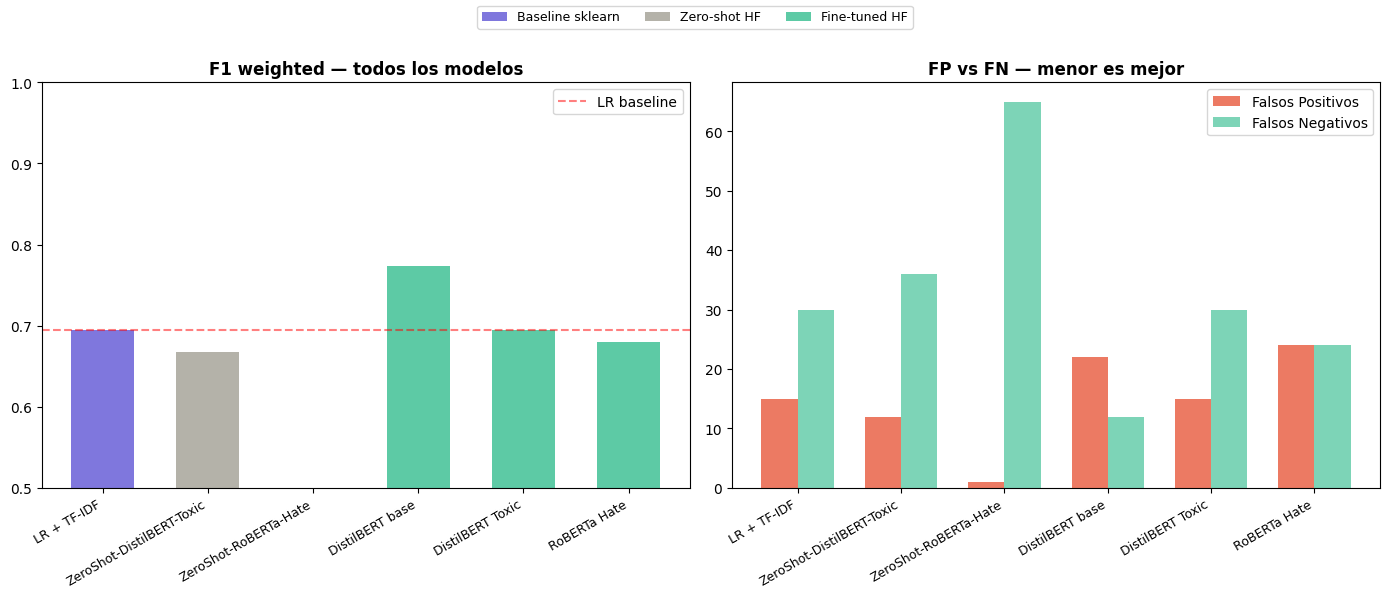

Guardado en reports/v2/nb08_comparativa_final.png


In [15]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#7F77DD' if 'LR' in r['Modelo'] else
          '#B4B2A9' if 'Zero' in r['Tipo'] else
          '#5DCAA5'
          for r in all_results]

models_short = [r['Modelo'].replace('(fine-tuned)','').replace('(nb06)','').strip()
                for r in all_results]

axes[0].bar(range(len(all_results)),
            [r['F1 weighted'] for r in all_results],
            color=colors, width=0.6)
axes[0].set_xticks(range(len(all_results)))
axes[0].set_xticklabels(models_short, rotation=30, ha='right', fontsize=9)
axes[0].set_title('F1 weighted — todos los modelos', fontweight='bold')
axes[0].set_ylim(0.5, 1.0)
axes[0].axhline(lr_ref['f1'] if lr_ref else 0.75,
                color='red', linestyle='--', alpha=0.5, label='LR baseline')
axes[0].legend()

# FP vs FN
x   = range(len(all_results))
fps = [r['FP'] for r in all_results]
fns = [r['FN'] for r in all_results]
w   = 0.35
axes[1].bar([i-w/2 for i in x], fps, w, label='Falsos Positivos', color='#E8593C', alpha=0.8)
axes[1].bar([i+w/2 for i in x], fns, w, label='Falsos Negativos', color='#5DCAA5', alpha=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(models_short, rotation=30, ha='right', fontsize=9)
axes[1].set_title('FP vs FN — menor es mejor', fontweight='bold')
axes[1].legend()

from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor='#7F77DD', label='Baseline sklearn'),
    Patch(facecolor='#B4B2A9', label='Zero-shot HF'),
    Patch(facecolor='#5DCAA5', label='Fine-tuned HF'),
]
fig.legend(handles=legend_els, loc='upper center', ncol=3, fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(PROJECT_ROOT / 'reports' / 'v2' / 'nb08_comparativa_final.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado en reports/v2/nb08_comparativa_final.png')

## 13. Análisis de errores del modelo ganador

Analizamos qué tipos de comentarios el modelo ganador sigue fallando.
Esto es importante porque nos dice si el problema es el modelo
o el dataset.

In [16]:
# Identificar el modelo ganador entre los fine-tuned
ft_results = [results_distilbert, results_toxic_distil, results_roberta]
best_ft    = max(ft_results, key=lambda r: r['f1'])
best_name  = best_ft['model']
best_preds = best_ft['preds']
best_probs = best_ft['probs']

print(f'Análisis de errores: {best_name}')

error_df = pd.DataFrame({
    'text'      : X_test.values,
    'real'      : y_test_arr,
    'pred'      : best_preds,
    'prob_toxic': best_probs,
})
error_df['error'] = error_df['real'] != error_df['pred']

fp_df = error_df[(error_df['real']==0) & (error_df['pred']==1)]
fn_df = error_df[(error_df['real']==1) & (error_df['pred']==0)]

print(f'Total test  : {len(error_df)}')
print(f'Errores     : {error_df["error"].sum()}')
print(f'Falsos Pos  : {len(fp_df)} (censuró comentarios OK)')
print(f'Falsos Neg  : {len(fn_df)} (hate speech que se escapó)')

Análisis de errores: DistilBERT base
Total test  : 150
Errores     : 34
Falsos Pos  : 22 (censuró comentarios OK)
Falsos Neg  : 12 (hate speech que se escapó)


In [17]:
print('FALSOS NEGATIVOS — hate speech que NO detectó:')
print('-' * 70)
for _, row in fn_df.head(6).iterrows():
    print(f'  Prob: {row["prob_toxic"]:.3f} | {row["text"][:120]}')
    print()

print('FALSOS POSITIVOS — comentarios OK mal censurados:')
print('-' * 70)
for _, row in fp_df.head(6).iterrows():
    print(f'  Prob: {row["prob_toxic"]:.3f} | {row["text"][:120]}')
    print()

FALSOS NEGATIVOS — hate speech que NO detectó:
----------------------------------------------------------------------
  Prob: 0.467 | They are protecting and serving us, from people like Michael Brown. The guy deserved to be killed, cry more about it...

  Prob: 0.452 | So the autopsy showed a number of wounds to the right arm making the scenario of him being shot with his hands raised a 

  Prob: 0.233 | Let's get this straight and present the facts as the mass media should have from the beginning. 18 yr old (by all legal 

  Prob: 0.071 | Ah, beautiful.

  Prob: 0.251 | Remember that time every other race rioted because someone of their race got shot by a white cop after attacking the off

  Prob: 0.368 | finally a black person with a unbiased opinion. An incredibly high percentage of black lives are lost among themselves a

FALSOS POSITIVOS — comentarios OK mal censurados:
----------------------------------------------------------------------
  Prob: 0.851 | Thats a real parent, a r

## 14. Registro en MLflow

Registramos todos los resultados en el mismo experimento del proyecto.

In [18]:
MLFLOW_DIR = PROJECT_ROOT / 'mlruns'
mlflow.set_tracking_uri(f'file://{MLFLOW_DIR}')
mlflow.set_experiment('Youtube_project_experiment')

for row in all_results:
    with mlflow.start_run(run_name=row['Modelo'].replace(' ','_')[:30]):
        mlflow.log_param('model',     row['Modelo'])
        mlflow.log_param('type',      row['Tipo'])
        mlflow.log_param('notebook',  '08_transformers')
        mlflow.log_metric('f1_weighted', row['F1 weighted'])
        mlflow.log_metric('roc_auc',     row['ROC-AUC'])
        mlflow.log_metric('fp',          row['FP'])
        mlflow.log_metric('fn',          row['FN'])
        print(f'  ✅ {row["Modelo"]}')

mlflow.log_artifact(str(PROJECT_ROOT / 'reports' / 'v2' / 'nb08_comparativa_final.png'))
print('MLflow actualizado')

  ✅ LR + TF-IDF (nb06)
  ✅ ZeroShot-DistilBERT-Toxic
  ✅ ZeroShot-RoBERTa-Hate
  ✅ DistilBERT base
  ✅ DistilBERT Toxic (fine-tuned)
  ✅ RoBERTa Hate
MLflow actualizado


## 15. Guardar el modelo ganador

Guardamos en `models/finetuned_hf/` que es exactamente la ruta
que espera `model_service.py` para el modelo 'Modelo fine-tuneado (local)'.

Esto significa que una vez ejecutado este notebook, el Streamlit
puede cargar y usar el modelo directamente.

In [19]:
SAVE_PATH = PROJECT_ROOT / 'models' / 'finetuned_hf'

print(f'Guardando {best_name} en {SAVE_PATH}...')

best_ft['trainer'].save_model(str(SAVE_PATH))
best_ft['tokenizer'].save_pretrained(str(SAVE_PATH))

# Guardar metadata para saber qué modelo es
meta = {
    'model_name'  : best_name,
    'f1_weighted' : best_ft['f1'],
    'roc_auc'     : best_ft['roc_auc'],
    'fp'          : best_ft['fp'],
    'fn'          : best_ft['fn'],
    'notebook'    : '08_transformers_finetuning',
}
with open(SAVE_PATH / 'model_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f'✅ Modelo guardado en: {SAVE_PATH}')
print(f'   El Streamlit lo carga como "Modelo fine-tuneado (local)"')
print(f'   en Settings → selección de modelo')

Guardando DistilBERT base en /mnt/c/Users/under/Documents/F5/3_Projects/Project_9_Equipo3/Project_YT/models/finetuned_hf...


Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.50s/it]

✅ Modelo guardado en: /mnt/c/Users/under/Documents/F5/3_Projects/Project_9_Equipo3/Project_YT/models/finetuned_hf
   El Streamlit lo carga como "Modelo fine-tuneado (local)"
   en Settings → selección de modelo


## 16. Conclusiones y decisiones

In [20]:
lr_f1 = lr_ref['f1'] if lr_ref else 0.75
delta  = (best_ft['f1'] - lr_f1) * 100

print(f"""
CONCLUSIONES — TRANSFORMERS vs LR+TF-IDF
{'='*55}
Modelos comparados: {len(all_results)}

Referencia LR + TF-IDF (nb06): F1={lr_f1:.4f}

Mejor modelo Transformer: {best_name}
  F1 weighted  : {best_ft['f1']:.4f}
  ROC-AUC      : {best_ft['roc_auc']:.4f}
  FP / FN      : {best_ft['fp']} / {best_ft['fn']}
  Mejora vs LR : {delta:+.2f}pp

¿Por que Transformers mejoran?
  Los modelos pre-entrenados entienden el contexto:
  'black thug' != 'black' + 'thug' por separado.
  TF-IDF trata cada palabra de forma independiente.

Modelo guardado:
  models/finetuned_hf/ → listo para el Streamlit
  Cargar en Settings como 'Modelo fine-tuneado (local)'

Limitación que persiste:
  Con 700 muestras de train de solo 8 videos,
  el gap de generalización sigue siendo un desafío.
  La solución real es mas datos de dominios diversos.
""")


CONCLUSIONES — TRANSFORMERS vs LR+TF-IDF
Modelos comparados: 6

Referencia LR + TF-IDF (nb06): F1=0.6944

Mejor modelo Transformer: DistilBERT base
  F1 weighted  : 0.7735
  ROC-AUC      : 0.8561
  FP / FN      : 22 / 12
  Mejora vs LR : +7.91pp

¿Por que Transformers mejoran?
  Los modelos pre-entrenados entienden el contexto:
  'black thug' != 'black' + 'thug' por separado.
  TF-IDF trata cada palabra de forma independiente.

Modelo guardado:
  models/finetuned_hf/ → listo para el Streamlit
  Cargar en Settings como 'Modelo fine-tuneado (local)'

Limitación que persiste:
  Con 700 muestras de train de solo 8 videos,
  el gap de generalización sigue siendo un desafío.
  La solución real es mas datos de dominios diversos.

